In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("D:/我的项目集/db-testing-project/data/experiment_data.csv", index_col=0)
df.head()

,group,impression,click,purchase
user_id,,,,
1,A,1,0,0
2,B,1,0,0
3,B,1,0,0
4,B,1,0,0
5,A,1,0,0


In [3]:
# 计算每个实验组的数据量
df['group'].value_counts()

group
B    50066
A    49934
Name: count, dtype: int64

In [4]:
# CTR（点击率）
ctr = df.groupby('group')['click'].mean()
ctr

group
A    0.049986
B    0.060400
Name: click, dtype: float64

我们可以发现

- A组 CTR = 0.049986
- B组 CTR = 0.060400

B组的点击率更高

In [5]:
# 点击数
clicks = df.groupby('group')['click'].sum()
clicks

group
A    2496
B    3024
Name: click, dtype: int64

In [6]:
# 展示数
impressions = df.groupby('group')['impression'].sum()
impressions

group
A    49934
B    50066
Name: impression, dtype: int64

In [7]:
ctr = clicks/impressions
ctr

group
A    0.049986
B    0.060400
dtype: float64

In [8]:
# 转化率(CVR)
purchase = df.groupby('group')['purchase'].sum()
cvr = purchase/clicks
cvr

group
A    0.205929
B    0.203373
dtype: float64

我们可以发现

- A组点击后20.6%购买
- B组点击后20.3%购买

In [9]:
# 指标表
result = pd.DataFrame({
    "impressions": df.groupby('group')['impression'].sum(),
    "clicks": df.groupby('group')['click'].sum(),
    "purchases": df.groupby('group')['purchase'].sum()
})

result['CTR'] = result['clicks']/result['impressions']
result['CVR'] = result['purchases']/result['clicks']

result

,impressions,clicks,purchases,CTR,CVR
group,,,,,
A,49934,2496,514,0.049986,0.205929
B,50066,3024,615,0.060400,0.203373


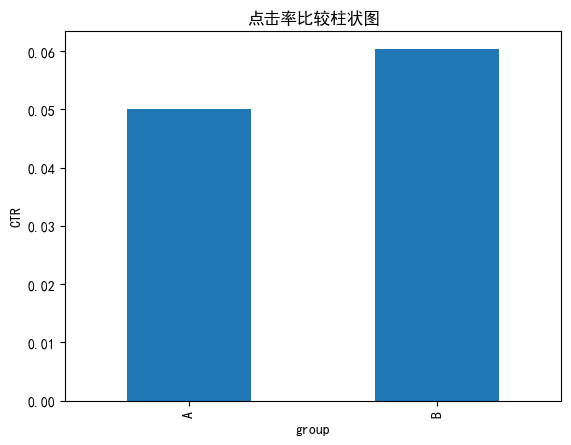

In [10]:
# 点击率对比柱状图
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif']=['SimHei']
plt.rcParams['axes.unicode_minus']=False

result['CTR'].plot(kind='bar')

plt.title('点击率比较柱状图')
plt.ylabel('CTR')
plt.show()

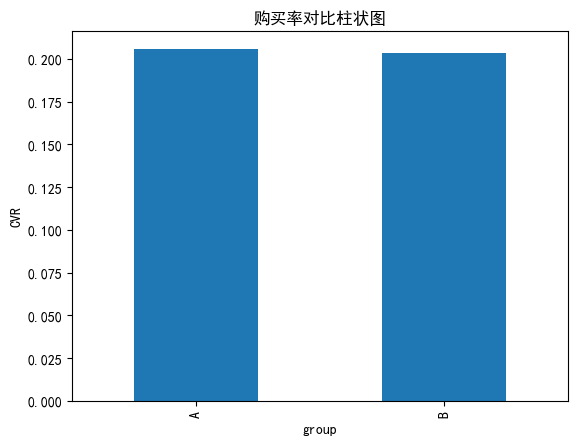

In [11]:
# 购买率对比柱状图
result['CVR'].plot(kind='bar')

plt.title('购买率对比柱状图')
plt.ylabel('CVR')
plt.show()

为评估新推荐算法的效果，本文计算了A组与B组的点击率（CTR）和转化率（CVR）。
实验结果表明：

A组CTR为5.0%，B组CTR为6.04%，B组点击率相较于A组提升约1.04%。

在转化率方面，A组CVR为20.6%，B组CVR为20.3%，两组差异较小。

初步结果表明，新推荐算法在点击行为方面具有一定提升效果。

---

CTR的差异究竟是随机波动，还是新算法真的有效呢？
所以我们需要用统计检验判断一下。

建立原假设H0：新算法与旧算法没有差异（CTR_A = CTR_B）

备择假设H1：新算法提升CTR（CTR_A ≠ CTR_B）

In [12]:
# 先把A组和B组数据分开
group_A = df[df['group'] == 'A']['click']
group_B = df[df['group'] == 'B']['click']

In [13]:
# 进行t检验
from scipy import stats

t_stats, p_value = stats.ttest_ind(group_A, group_B)

print("t值", t_stats)
print("p值", p_value)

t值 -7.212210587534962
p值 5.543855229186043e-13


In [14]:
# 判断显著性
print(p_value < 0.05)

True


In [15]:
# 提升幅度
ctr_A = group_A.mean()
ctr_B = group_B.mean()

lift = round((ctr_B - ctr_A)/ctr_A * 100, 2)
print("新方案CTR提升幅度：", lift,"%")

新方案CTR提升幅度： 20.83 %


为判断新推荐算法是否能够显著提升用户点击率，本研究采用独立样本t检验对实验组与对照组的点击率进行统计分析。

检验结果表明，实验组CTR为5.0%，对照组CTR为6.04%。

t检验得到 p-value小于显著性水平0.05。

因此可以拒绝原假设，认为新推荐算法在统计意义上显著提升了用户点击率。

---

不止是判断“是否显著”，而是估计效果提升可能落在什么范围

In [16]:
n1 = len(group_A)
n2 = len(group_B)

import numpy as np

diff = ctr_B - ctr_A

se = np.sqrt(
    ctr_A*(1-ctr_A)/n1 +
    ctr_B*(1-ctr_B)/n2
)

ci_low = diff - 1.96*se
ci_high = diff + 1.96*se

print("CTR_A:", ctr_A)
print("CTR_B:", ctr_B)
print("差值:", diff)
print("95% CI:", ci_low, ci_high)

CTR_A: 0.04998598149557416
CTR_B: 0.06040027164143331
差值: 0.01041429014585915
95% CI: 0.00758444903961402 0.013244131252104281


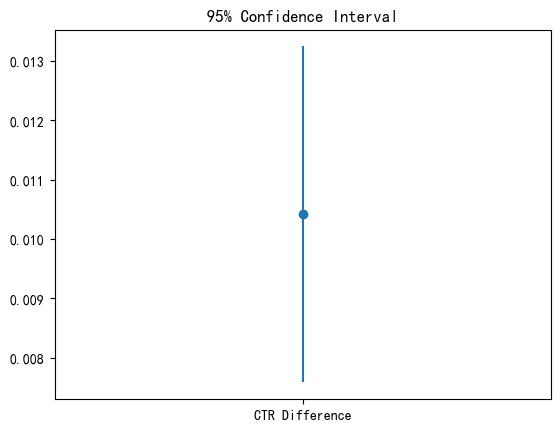

In [17]:
plt.errorbar(
    x=["CTR Difference"],
    y=[diff],
    yerr=[1.96*se],
    fmt='o'
)

plt.title("95% Confidence Interval")

plt.show()

为进一步评估实验效果的稳定性，本研究计算了实验组与对照组点击率差值的95%置信区间。

结果显示，CTR差值为1.04%，其95%置信区间为[0.76%，1.33%]。

由于置信区间不包含0，说明实验组点击率显著高于对照组，新推荐算法在统计意义上具有显著提升效果